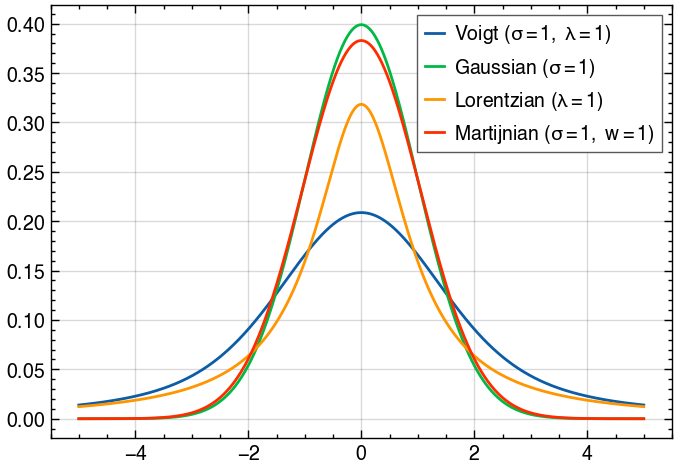

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import wedme.apply.dev
from ramlab.simulate.linespreadfunction.functions import gaussian, voigt, lorentzian, rect, martijnian

x = np.linspace(-5, 5, 1000)
v = voigt(x, 1, 1)
g = gaussian(x, 1)
l = lorentzian(x, 1)
r = rect(x, 2)
m = martijnian(x, 1, 1)

plt.figure()
plt.plot(x, v, label=r"Voigt ($\sigma=1,\ \lambda=1$)")
plt.plot(x, g, label=r"Gaussian ($\sigma=1$)")
plt.plot(x, l, label=r"Lorentzian ($\lambda=1$)")
plt.plot(x, m, label=r"Martijnian ($\sigma=1,\ w=1$)")

plt.legend()
plt.show()

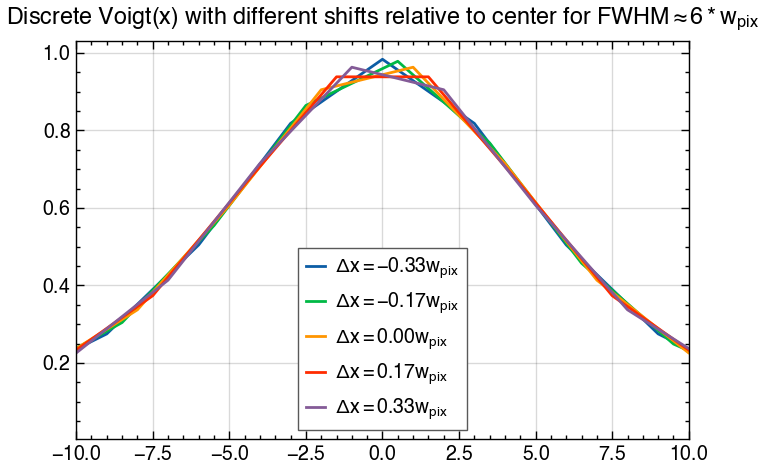

In [39]:
w_pix = 3
x_discrete = np.arange(-20, 20, w_pix)

plt.figure()
for dx in np.linspace(-1, 1, 5):
    v_discrete = voigt(x_discrete+dx, 3, 4) / 0.06
    plt.plot(x_discrete+dx, v_discrete, label=rf"$\Delta x = {dx/w_pix:.2f} w_{{pix}} $" )

plt.title(r"Discrete Voigt(x) with different shifts relative to center for $FWHM\approx 6*w_{{pix}}$")
plt.legend()
plt.xlim(-10, 10)
plt.show()

**Observation**: it can result in asymmetries, or a 5% apparent change in intensity.  
**Solution**: sample the linespreadfunction on a smaller grid than the measurement.  
**Implementation**: see below  

We want to approximate $f(x)$ with $f_i(x_i)$ as best as we can. 
The integral of $\int f(x) dx$ should equal the discrete integral $\sum_i \Delta x_i f_i (x_i)$. This means that the discrete approximation depends on $\Delta x_i$. If the grid is not linearly spaced, the discrete function will change depending on the position, which should be counteracted within $f_i$.

In [48]:
dx = np.diff(x_discrete)
x_subsample_start = np.min(x_discrete) - dx[0]/2
x_subsample_end = np.max(x_discrete) + dx[-1]/2
x_subsample_middle = x_discrete[:-1] + dx/2

# Append these points
x_subsample_range = np.concatenate(([x_subsample_start], x_subsample_middle, [x_subsample_end]))

N_subsample = 11 # Let's stick to odd
dx_subsample_range = np.diff(x_subsample_range)
x_subsample_2d = np.linspace(-0.5, 0.5, N_subsample)[:, np.newaxis] * dx_subsample_range

print(x_discrete.shape)
print(x_subsample_2d.shape)

(14,)
(11, 14)


Execution time: 0ms
Execution time: 1ms


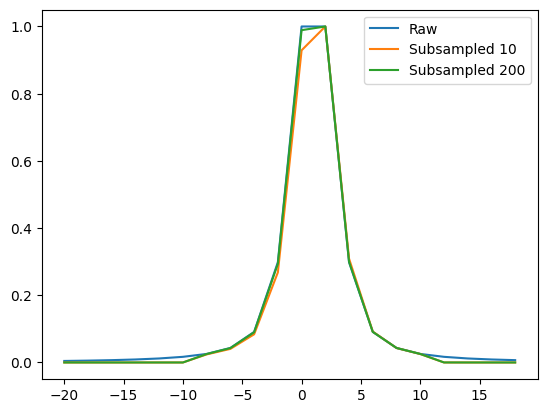

In [27]:
from ramlab.simulate import subsampled, simulate_raw
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-20, 20, 2)
x_stick = np.array([1])
I_stick = np.ones_like(x_stick)

s = 1
l = 1
I_sub = subsampled(x, x_stick, I_stick, s, l, N_subsample=10)
I_sub0 = subsampled(x, x_stick, I_stick, s, l, N_subsample=200)
I_raw = simulate_raw(x, x_stick, I_stick, s, l)

plt.figure()
plt.plot(x, I_raw / np.max(I_raw), label="Raw")
plt.plot(x, I_sub / np.max(I_sub), label="Subsampled 10")
plt.plot(x, I_sub0 / np.max(I_sub0), label="Subsampled 200")

plt.legend()
plt.show()